# Lab 07 — Named Entity Recognition (NER)

> **GraphoLab** | Forensic Graphology Laboratory

**Model:** `Babelscape/wikineural-multilingual-ner` (Hugging Face)  
**Task:** Extract named entities (persons, organisations, locations) from text  
**Forensic use case:** Analysing handwritten documents, anonymous letters, contracts, court exhibits

---

## How NER Works

Named Entity Recognition is a sequence-labelling task: the model assigns a label to every token in the input text.
The labels follow the **BIO** (Beginning–Inside–Outside) scheme:

| Tag | Meaning |
|-----|---------|
| `B-PER` | Beginning of a **person** name |
| `I-PER` | Continuation of a person name |
| `B-ORG` | Beginning of an **organisation** |
| `B-LOC` | Beginning of a **location** |
| `B-MISC` | Beginning of a **miscellaneous** entity |
| `O` | Outside any entity |

**WikiNEural** is a BERT-based model fine-tuned on automatically annotated Wikipedia corpora in 9 languages (including Italian), making it well-suited for multilingual forensic documents.

## GraphoLab Core — Quick Start

> The production implementation of NER is available in [`core/ner.py`](../core/ner.py).
> It uses **WikiNEural** (`Babelscape/wikineural-multilingual-ner`) with lazy thread-safe model loading
> and returns both highlighted spans and a Markdown summary table.
>
> Run the cell below to import it directly. The remaining cells implement the same pipeline
> from scratch for educational purposes.

In [1]:
# GraphoLab Core — production usage
# Run this cell to use the shared core module instead of the notebook implementation below.
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

from core.ner import ner_extract, get_ner

# Example: extract named entities from OCR text
# text = "Mario Rossi ha firmato il contratto a Roma il 12 marzo 2024."
# highlighted_spans, markdown_table = ner_extract(text)
# print(markdown_table)
print("core.ner imported — ner_extract() ready.")

core.ner imported — ner_extract() ready.


## Setup

In [ ]:
# Install dependencies if not already installed
# !pip install transformers torch

In [3]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import torch
from transformers import pipeline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import HTML, display

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.6.0+cu124
Device: cuda


## Load the Model

The model is downloaded from Hugging Face on first run (~700 MB) and cached locally.

In [4]:
MODEL_NAME = "Babelscape/wikineural-multilingual-ner"
DEVICE = 0 if torch.cuda.is_available() else -1

print(f"Loading {MODEL_NAME} ...")
nlp = pipeline(
    "ner",
    model=MODEL_NAME,
    aggregation_strategy="simple",  # merges B/I tokens into single spans
    device=DEVICE,
)
print("Model ready.")

Loading Babelscape/wikineural-multilingual-ner ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: Babelscape/wikineural-multilingual-ner
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model ready.


## Helper Functions

In [5]:
# Entity type colours for visualisation
COLORS = {
    "PER":  ("#ffcccc", "Persona"),
    "ORG":  ("#cce0ff", "Organizzazione"),
    "LOC":  ("#ccffcc", "Luogo"),
    "MISC": ("#ffe0b2", "Varie"),
}


def run_ner(text: str) -> list[dict]:
    """Run NER and return a list of entity dicts."""
    return nlp(text)


def highlight_html(text: str, entities: list[dict]) -> str:
    """Return an HTML string with inline-highlighted entity spans."""
    html = ""
    prev = 0
    for ent in entities:
        s, e = ent["start"], ent["end"]
        label = ent["entity_group"]
        color, label_it = COLORS.get(label, ("#eeeeee", label))
        html += text[prev:s]
        html += (
            f'<mark style="background:{color};padding:2px 4px;border-radius:3px;">' 
            f'{text[s:e]}<sup style="font-size:0.7em;margin-left:2px;">{label_it}</sup></mark>'
        )
        prev = e
    html += text[prev:]
    return f'<p style="font-size:1.1em;line-height:1.8;font-family:serif">{html}</p>'


def print_entities(entities: list[dict]) -> None:
    """Print a summary table of extracted entities."""
    if not entities:
        print("Nessuna entità trovata.")
        return
    print(f"{'Tipo':<18} {'Entità':<30} {'Confidenza'}")
    print("-" * 58)
    labels = {k: v[1] for k, v in COLORS.items()}
    for ent in entities:
        tipo = labels.get(ent['entity_group'], ent['entity_group'])
        print(f"{tipo:<18} {ent['word']:<30} {ent['score']:.1%}")

## Demo 1 — Testo Italiano (Documento Legale)

Eseguiamo il NER su un testo di esempio in italiano che simula una dichiarazione giurata.

In [6]:
testo_it = (
    "Io sottoscritto Mario Rossi, nato a Roma il 12 marzo 1950, residente in Corso Italia 27, "
    "Napoli, nomino mio erede universale Giovanni Costa, residente in Piazza Duomo 78, Napoli. "
    "Lascio il possesso del mio conto bancario presso IBA e la proprieta dell'appartamento "
    "sito in Via Garibaldi 21, Milano. Fatto a Firenze, il 15 giugno 2024."
)

entities_it = run_ner(testo_it)
display(HTML(highlight_html(testo_it, entities_it)))
print()
print_entities(entities_it)


Tipo               Entità                         Confidenza
----------------------------------------------------------
Persona            Mario Rossi                    100.0%
Luogo              Roma                           100.0%
Luogo              Corso Italia                   98.8%
Luogo              Napoli                         99.9%
Persona            Giovanni Costa                 100.0%
Luogo              Piazza Duomo                   99.7%
Luogo              Napoli                         99.9%
Organizzazione     IBA                            82.4%
Luogo              Via Garibaldi                  99.7%
Luogo              Milano                         100.0%
Luogo              Firenze                        100.0%


## Demo 2 — Testo Inglese

Il modello WikiNEural supporta più lingue. Verifichiamo che funzioni anche su testo inglese.

In [7]:
testo_en = (
    "John Smith signed the contract on behalf of Acme Corp in New York on 12 March 2024. "
    "The suspect, Maria Rossi, was last seen near the Colosseum in Rome by officers from Interpol."
)

entities_en = run_ner(testo_en)
display(HTML(highlight_html(testo_en, entities_en)))
print()
print_entities(entities_en)


Tipo               Entità                         Confidenza
----------------------------------------------------------
Persona            John Smith                     99.9%
Organizzazione     Acme Corp                      99.2%
Luogo              New York                       99.9%
Persona            Maria Rossi                    100.0%
Luogo              Colosseum                      99.2%
Luogo              Rome                           99.8%
Organizzazione     Interpol                       99.6%


## Demo 3 — Pipeline HTR → NER

In un flusso forense reale si esegue prima il riconoscimento del testo (HTR) e poi il NER.
Carichiamo TrOCR e colleghiamo le due fasi.

In [8]:
import cv2
import numpy as np
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

TROCR_MODEL = "microsoft/trocr-base-handwritten"
TROCR_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading {TROCR_MODEL} ...")
processor = TrOCRProcessor.from_pretrained(TROCR_MODEL)
trocr = VisionEncoderDecoderModel.from_pretrained(TROCR_MODEL).to(TROCR_DEVICE)
trocr.eval()
print("TrOCR ready.")

Loading microsoft/trocr-base-handwritten ...


The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TrOCR ready.


In [9]:
def segment_lines(pil_img: Image.Image, min_gap: int = 5, pad: int = 6) -> list[Image.Image]:
    """Split a multi-line image into individual line crops via horizontal projection."""
    gray = np.array(pil_img.convert("L"))
    _, binary = cv2.threshold(
        cv2.GaussianBlur(gray, (3, 3), 0), 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU,
    )
    proj = binary.sum(axis=1)
    in_line, start, segments = False, 0, []
    for r, v in enumerate(proj):
        if v > 0 and not in_line:
            in_line, start = True, r
        elif v == 0 and in_line:
            if r - start >= min_gap:
                segments.append((start, r))
            in_line = False
    if in_line:
        segments.append((start, len(proj)))
    if not segments:
        return [pil_img]
    h, w = gray.shape
    return [pil_img.crop((0, max(0, y0 - pad), w, min(h, y1 + pad))) for y0, y1 in segments]


def htr_transcribe(image_path: str | Path) -> str:
    """Transcribe a (possibly multi-line) handwritten image using TrOCR."""
    pil_img = Image.open(image_path).convert("RGB")
    lines = segment_lines(pil_img)
    texts = []
    for line_img in lines:
        pv = processor(images=line_img, return_tensors="pt").pixel_values.to(TROCR_DEVICE)
        with torch.no_grad():
            ids = trocr.generate(pv)
        texts.append(processor.batch_decode(ids, skip_special_tokens=True)[0])
    return " ".join(texts)


# ─── Change this path to your own handwritten document ────────────────────────
IMAGE_PATH = Path("../data/samples/handwritten_multiline_01.png")
# ─────────────────────────────────────────────────────────────────────────────

if IMAGE_PATH.exists():
    # Step 1: HTR transcription
    transcribed = htr_transcribe(IMAGE_PATH)
    print("=== Trascrizione HTR ===")
    print(transcribed)

    # Step 2: NER on transcribed text
    entities_htr = run_ner(transcribed)
    print("\n=== Entità estratte ===")
    display(HTML(highlight_html(transcribed, entities_htr)))
    print()
    print_entities(entities_htr)
else:
    print(f"File non trovato: {IMAGE_PATH}")
    print("Modifica IMAGE_PATH con il percorso di un documento manoscritto.")

=== Trascrizione HTR ===
to sottoscritto Mario Bianchi , Nato a Firenze . il 3 aprile 1978 , dichiaro quanto segue . In data odierna he ricevuto la somma 1882 di tremila euro da parte del Sig. Carlo Verdi , a titolo di rimborso spese viaggio . Firenze , 15 giugno 2024-

=== Entità estratte ===



Tipo               Entità                         Confidenza
----------------------------------------------------------
Persona            Mario Bianchi                  100.0%
Luogo              Firenze                        100.0%
Persona            Carlo Verdi                    97.9%
Luogo              Firenze                        99.9%


## Demo 4 — Analisi della Distribuzione delle Entità

In un caso forense con molti documenti è utile visualizzare quante entità di ogni tipo compaiono.

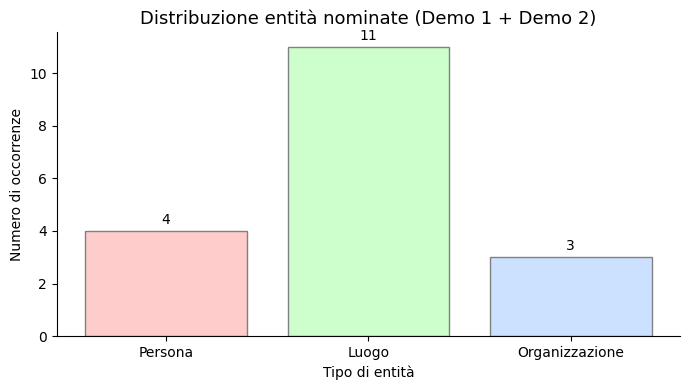

In [10]:
# Combine entities from all demos
all_entities = entities_it + entities_en

from collections import Counter

label_counts = Counter(e["entity_group"] for e in all_entities)
labels_it = {k: v[1] for k, v in COLORS.items()}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    [labels_it.get(k, k) for k in label_counts],
    label_counts.values(),
    color=[COLORS.get(k, ("#cccccc", ""))[0] for k in label_counts],
    edgecolor="grey",
)
ax.bar_label(bars, padding=3)
ax.set_title("Distribuzione entità nominate (Demo 1 + Demo 2)", fontsize=13)
ax.set_ylabel("Numero di occorrenze")
ax.set_xlabel("Tipo di entità")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Analisi della Confidenza

Il modello restituisce un punteggio di confidenza per ogni entità. 
Entità con confidenza bassa meritano una revisione manuale.

In [11]:
CONFIDENCE_THRESHOLD = 0.80

print(f"Entità con confidenza < {CONFIDENCE_THRESHOLD:.0%} (da verificare manualmente):")
low_conf = [e for e in all_entities if e["score"] < CONFIDENCE_THRESHOLD]
if low_conf:
    for e in low_conf:
        tipo = labels_it.get(e['entity_group'], e['entity_group'])
        print(f"  [{tipo}] '{e['word']}' — {e['score']:.1%}")
else:
    print("  Nessuna entità sotto soglia.")

Entità con confidenza < 80% (da verificare manualmente):
  Nessuna entità sotto soglia.


## Note Forensi

- Il modello WikiNEural supporta **9 lingue** (italiano, inglese, tedesco, spagnolo, francese, russo, olandese, polacco, cinese).
- In un flusso forense, il NER viene tipicamente applicato **dopo** la trascrizione HTR (vedi Demo 3).
- Le entità estratte possono essere usate per costruire un **grafo delle relazioni** tra persone, luoghi e organizzazioni menzionati in un documento.
- La confidenza delle entità dipende dalla qualità della trascrizione: errori OCR si propagano al NER.
- Per documenti in italiano con terminologia giuridica specializzata, considerare il fine-tuning su un corpus forense.

---

**Lab precedente →** [06 — Analisi delle Caratteristiche Grafologiche](06_graphological_feature_analysis.ipynb)
